<a href="https://colab.research.google.com/github/ashika-06/IIITH-AIML-Labs/blob/main/HAR_PROJECT/HAR_01_New_Data_Prep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HAR — Part 1: Data Prep

Extracts frames from UCF50, builds the train/val/test split, and saves everything to Google
Drive.

In [14]:
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_DIR = '/content/drive/MyDrive/HAR_project_new'
os.makedirs(DRIVE_DIR, exist_ok=True)
print("Saving/loading all checkpoints from:", DRIVE_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saving/loading all checkpoints from: /content/drive/MyDrive/HAR_project_new


In [15]:
import numpy as np
import datetime as dt
import tensorflow as tf
from collections import deque
import matplotlib.pyplot as plt

# Using a wildcard import is common in this tutorial, though explicit is often better
from moviepy.editor import *
%matplotlib inline

from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import *
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import plot_model

In [16]:
import random

seed_constant = 27
np.random.seed(seed_constant)
random.seed(seed_constant)
tf.random.set_seed(seed_constant)

In [17]:
import os

# 1. Clean up any partial or corrupted downloads from previous attempts
!rm -f UCF50.rar UCF50.rar.*
!rm -rf UCF50/

# 2. Download the full UCF50 Dataset cleanly
!wget --no-check-certificate https://www.crcv.ucf.edu/data/UCF50.rar

# 3. Extract the Dataset (using the exact flags that handle overwriting correctly)
!unrar x -o+ UCF50.rar

Streaming output truncated to the last 5000 lines.
Extracting  UCF50/HorseRace/v_HorseRace_g16_c03.avi                       23%  OK 
Extracting  UCF50/HorseRace/v_HorseRace_g16_c04.avi                       23%  OK 
Extracting  UCF50/HorseRace/v_HorseRace_g16_c05.avi                       23%  OK 
Extracting  UCF50/HorseRace/v_HorseRace_g17_c01.avi                       23%  OK 
Extracting  UCF50/HorseRace/v_HorseRace_g17_c02.avi                       23%  OK 
Extracting  UCF50/HorseRace/v_HorseRace_g17_c03.avi                       23%  OK 
Extracting  UCF50/HorseRace/v_HorseRace_g17_c04.avi                       23%  OK 
Extracting  UCF50/HorseRace/v_HorseRace_g17_c05.avi                       23%  OK 
Extracting  UCF50/HorseRace/v_HorseRace_g18_c01.avi                       23%  OK 
Extracting  UCF50/HorseRace/v_HorseRace_g18_c02.avi                       23%  OK 
Extracting  UCF50/HorseRace/v

In [18]:
import os

# Count total folders (classes) and total files (videos)
total_folders = 0
total_files = 0

for root, dirs, files in os.walk('UCF50'):
    if dirs:
        total_folders = len(dirs)
    total_files += len(files)

print(f"Total Categories: {total_folders}")
print(f"Total Video Files: {total_files}")

Total Categories: 50
Total Video Files: 6681


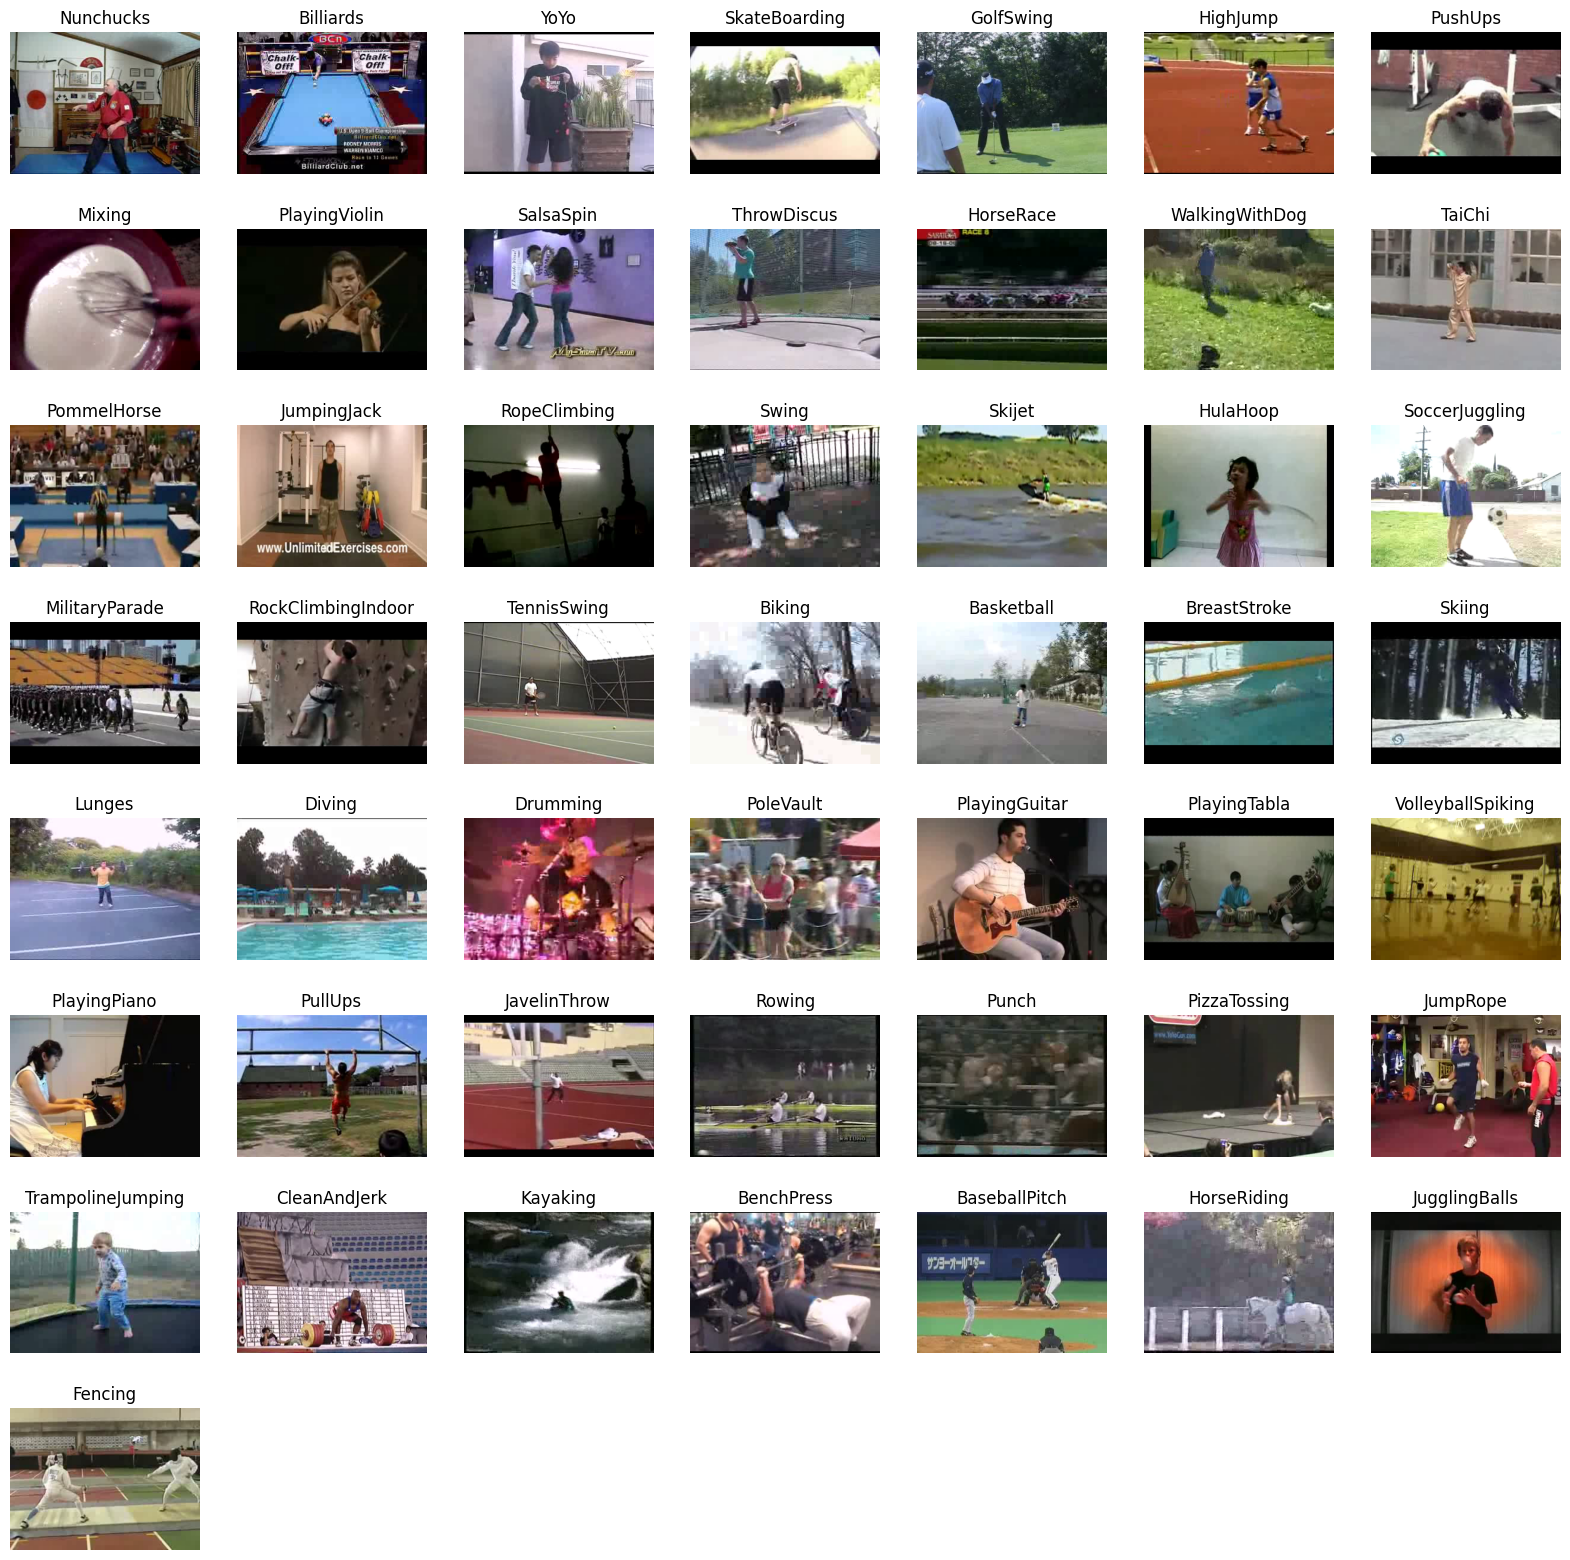

In [19]:
import os
import random
import matplotlib.pyplot as plt
import cv2
import math

# Create a Matplotlib figure
plt.figure(figsize=(20, 20))

# Get the names of all categories/classes
all_classes_names = os.listdir('UCF50')

# Determine the number of classes to sample (maximum of available classes)
num_samples = len(all_classes_names)

# Generate a list of random indices to select categories
random_range = random.sample(range(num_samples), num_samples)

# Calculate dynamic subplot grid (e.g., square or close to it)
rows = math.ceil(math.sqrt(num_samples))
cols = math.ceil(num_samples / rows)

# Iterate through the selected random indices
for counter, random_index in enumerate(random_range):
    selected_class_name = all_classes_names[random_index]

    # Get a list of all videos in the selected class
    video_files_names_list = os.listdir(os.path.join('UCF50', selected_class_name))

    # Select a random video from the list
    selected_video_file_name = random.choice(video_files_names_list)

    # Read the first frame of the video
    video_reader = cv2.VideoCapture(os.path.join('UCF50', selected_class_name, selected_video_file_name))
    success, frame = video_reader.read()
    video_reader.release()

    # Display the frame in the plot
    if success:
        plt.subplot(rows, cols, counter + 1)
        plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        plt.title(selected_class_name)
        plt.axis('off')

plt.show()

In [20]:
# Specify the height and width to which each video frame will be resized
# NOTE: bumped from 64x64 -> 128x128. MobileNetV2's pretrained ImageNet
# features are much stronger at this resolution, and 128 is still small
# enough to keep training/inference fast.
IMAGE_HEIGHT, IMAGE_WIDTH = 128, 128

# Specify the number of frames of a video that will be fed to the model as one sequence
SEQUENCE_LENGTH = 20

# Specify the directory containing the UCF50 dataset
DATASET_DIR = "UCF50"

# Specify the list containing the names of the classes used for training.
# Extended from 4 -> 15 classes for a stronger project scope. This mix is
# chosen deliberately, not randomly:
#   - Confusable/similar pairs, so the confusion matrix has something
#     interesting to say (a good discussion point for your report/viva):
#       HorseRiding  vs HorseRace
#       PushUps      vs PullUps
#       JumpRope     vs JumpingJack
#       PlayingGuitar vs PlayingViolin
#   - Clearly distinct actions, so overall accuracy stays reasonable and the
#     model isn't overwhelmed by only-hard cases:
#       BaseballPitch, CleanAndJerk, Skiing, Diving, Drumming,
#       TennisSwing, WalkingWithDog
# Ensure these names match the folder names exactly in your 'UCF50' directory.
CLASSES_LIST = [
    "BaseballPitch", "HorseRiding", "CleanAndJerk", "HorseRace",
    "PushUps", "PullUps", "JumpRope", "JumpingJack",
    "PlayingGuitar", "PlayingViolin", "Skiing", "Diving",
    "Drumming", "TennisSwing", "WalkingWithDog"
]


In [21]:
def frames_extraction(video_path):
    # Declare a list to store video frames.
    frames_list = []

    # Read the Video File using the VideoCapture object.
    video_reader = cv2.VideoCapture(video_path)

    # Get the total number of frames in the video.
    video_frames_count = int(video_reader.get(cv2.CAP_PROP_FRAME_COUNT))

    # Calculate the interval after which frames will be added to the list.
    # This ensures we get exactly 20 frames regardless of video length.
    skip_frames_window = max(int(video_frames_count / SEQUENCE_LENGTH), 1)

    # Iterate through the video frames.
    for frame_counter in range(SEQUENCE_LENGTH):

        # Set the current frame position of the video.
        video_reader.set(cv2.CAP_PROP_POS_FRAMES, frame_counter * skip_frames_window)

        # Reading the frame from the video.
        success, frame = video_reader.read()

        # Check if video frame is not successfully read then break the loop
        if not success:
            break

        # Resize the frame to fixed height and width
        resized_frame = cv2.resize(frame, (IMAGE_HEIGHT, IMAGE_WIDTH))

        # Normalize the frame (convert to range 0-1). Explicit float32, not the
        # numpy-default float64 -- halves the memory footprint of the whole
        # dataset, which is what caused the earlier out-of-memory crash.
        normalized_frame = (resized_frame / 255.0).astype(np.float32)

        # Append to our list
        frames_list.append(normalized_frame)

    # Release the video object
    video_reader.release()

    return frames_list


In [22]:
def create_dataset(cache_dir="feature_cache"):
    os.makedirs(cache_dir, exist_ok=True)

    # First pass: just list every candidate video (cheap, no frame reading yet)
    video_entries = []
    for class_index, class_name in enumerate(CLASSES_LIST):
        class_dir = os.path.join(DATASET_DIR, class_name)
        for file_name in os.listdir(class_dir):
            video_entries.append((class_index, os.path.join(class_dir, file_name)))

    n_candidates = len(video_entries)
    print(f"Found {n_candidates} candidate videos across {len(CLASSES_LIST)} classes")

    # Pre-allocate an on-disk memmap sized for the worst case (all candidates valid).
    # Writing directly into this avoids ever holding a giant Python list of all
    # videos' frames in RAM at once -- that intermediate list + its conversion
    # to a numpy array is what caused the earlier crash.
    X_path = os.path.join(cache_dir, "X.dat")
    X_memmap = np.memmap(X_path, dtype=np.float32, mode="w+",
                          shape=(n_candidates, SEQUENCE_LENGTH, IMAGE_HEIGHT, IMAGE_WIDTH, 3))

    labels, video_files_paths = [], []
    valid_count = 0

    for class_index, video_file_path in video_entries:
        frames = frames_extraction(video_file_path)
        if len(frames) == SEQUENCE_LENGTH:
            X_memmap[valid_count] = np.array(frames, dtype=np.float32)
            labels.append(class_index)
            video_files_paths.append(video_file_path)
            valid_count += 1

        if valid_count % 50 == 0 and valid_count > 0:
            print(f"  ...processed {valid_count} valid videos so far")

    X_memmap.flush()
    print(f"Done: {valid_count}/{n_candidates} videos had a full {SEQUENCE_LENGTH}-frame sequence")

    # Re-open as a read-only memmap trimmed to just the valid rows -- this is
    # still disk-backed, NOT loaded fully into RAM. Numpy only pages in the
    # slices you actually touch (e.g. during train_test_split / model.fit).
    features = np.memmap(X_path, dtype=np.float32, mode="r",
                          shape=(n_candidates, SEQUENCE_LENGTH, IMAGE_HEIGHT, IMAGE_WIDTH, 3))[:valid_count]
    labels = np.array(labels)

    return features, labels, video_files_paths

# Create the dataset
features, labels, video_files_paths = create_dataset()


Found 2091 candidate videos across 15 classes
  ...processed 50 valid videos so far
  ...processed 100 valid videos so far
  ...processed 150 valid videos so far
  ...processed 200 valid videos so far
  ...processed 250 valid videos so far
  ...processed 300 valid videos so far
  ...processed 350 valid videos so far
  ...processed 400 valid videos so far
  ...processed 450 valid videos so far
  ...processed 500 valid videos so far
  ...processed 550 valid videos so far
  ...processed 600 valid videos so far
  ...processed 650 valid videos so far
  ...processed 700 valid videos so far
  ...processed 750 valid videos so far
  ...processed 800 valid videos so far
  ...processed 850 valid videos so far
  ...processed 900 valid videos so far
  ...processed 950 valid videos so far
  ...processed 1000 valid videos so far
  ...processed 1050 valid videos so far
  ...processed 1100 valid videos so far
  ...processed 1150 valid videos so far
  ...processed 1200 valid videos so far
  ...processed

In [23]:
one_hot_encoded_labels=to_categorical(labels)

In [24]:
# IMPORTANT: we split on INDICES only, never on the actual video data. This
# means `features` (the memmap) never gets copied into RAM in one big chunk.

all_indices = np.arange(len(features))

train_val_idx, test_idx, train_val_labels, test_labels = train_test_split(
    all_indices, one_hot_encoded_labels,
    test_size=0.25, shuffle=True, random_state=seed_constant,
    stratify=labels
)
train_idx, val_idx, train_labels, val_labels = train_test_split(
    train_val_idx, train_val_labels,
    test_size=0.2, shuffle=True, random_state=seed_constant,
    stratify=np.argmax(train_val_labels, axis=1)
)

print(f"Train: {len(train_idx)}  Val: {len(val_idx)}  Test: {len(test_idx)}")


# --- RECIPE: class-balanced weighting -------------------------------------
from sklearn.utils.class_weight import compute_class_weight

train_labels_int = np.argmax(train_labels, axis=1)
class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(CLASSES_LIST)),
    y=train_labels_int
)
CLASS_WEIGHTS = {i: w for i, w in enumerate(class_weight_values)}
print("Class weights (higher = rarer class in training data):")
for i, cls in enumerate(CLASSES_LIST):
    print(f"  {cls:<16} {CLASS_WEIGHTS[i]:.3f}")


Train: 1254  Val: 314  Test: 523
Class weights (higher = rarer class in training data):
  BaseballPitch    0.939
  HorseRiding      0.708
  CleanAndJerk     1.248
  HorseRace        1.100
  PushUps          1.306
  PullUps          1.161
  JumpRope         0.939
  JumpingJack      1.130
  PlayingGuitar    0.871
  PlayingViolin    1.393
  Skiing           0.972
  Diving           0.909
  Drumming         0.862
  TennisSwing      0.836
  WalkingWithDog   1.130


## Persist everything to Google Drive

This is the checkpoint that makes Parts 2 and 3 fast and crash-safe. The memmap file itself
(`feature_cache/X.dat`) is copied to Drive as-is; labels, split indices, and class weights are
saved as small `.npy`/`.json` files.

In [25]:
import shutil, json as _json

# Copy the memmap data file + metadata needed to reconstruct it
shutil.copy('feature_cache/X.dat', f'{DRIVE_DIR}/X.dat')

np.save(f'{DRIVE_DIR}/labels.npy', labels)
np.save(f'{DRIVE_DIR}/one_hot_encoded_labels.npy', one_hot_encoded_labels)
np.save(f'{DRIVE_DIR}/train_idx.npy', train_idx)
np.save(f'{DRIVE_DIR}/val_idx.npy', val_idx)
np.save(f'{DRIVE_DIR}/test_idx.npy', test_idx)
np.save(f'{DRIVE_DIR}/train_labels.npy', train_labels)
np.save(f'{DRIVE_DIR}/val_labels.npy', val_labels)
np.save(f'{DRIVE_DIR}/test_labels.npy', test_labels)

meta = {
    "n_videos": int(len(features)),
    "SEQUENCE_LENGTH": SEQUENCE_LENGTH,
    "IMAGE_HEIGHT": IMAGE_HEIGHT,
    "IMAGE_WIDTH": IMAGE_WIDTH,
    "CLASSES_LIST": CLASSES_LIST,
    "CLASS_WEIGHTS": {str(k): float(v) for k, v in CLASS_WEIGHTS.items()},
}
with open(f'{DRIVE_DIR}/meta.json', 'w') as f:
    _json.dump(meta, f, indent=2)

print("✅ All data prep artifacts saved to Google Drive.")
print("You can now close this notebook and open Part 2 (Training) --")
print("it will load everything from Drive without redoing extraction.")


✅ All data prep artifacts saved to Google Drive.
You can now close this notebook and open Part 2 (Training) --
it will load everything from Drive without redoing extraction.
